# Cluster analysis with K-means

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat 
pel següent sistema d'EDOs, on $f(t)=sin(t)$.
$$x'=y + \epsilon f(t)$$ $$y'=x-x^3$$

In [1053]:
%load_ext autoreload
%autoreload 2
import numpy as np
from src import (edo_duffing, generar_condicions_inicials,
grafica_punts, generar_trajectories, calcula_matriu_pesos, sparcify,
grafica_trajectories, grafica_clusters, imprimeix_estadistics, 
calcula_matriu_grau, calcula_vaps_veps, calcula_num_clusters,
troba_clusters)
np.set_printoptions(precision=3, suppress=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Paràmetres

In [1054]:
epsilon = 0
funcio_soroll = np.sin
dimensio = 2
t_span = (0, 4*np.pi)
t_steps = 400
t_valors = np.linspace(t_span[0], t_span[1], t_steps)
x_min, x_max = (-1.6, 1.6)
y_min, y_max = (-1, 1)
espai_entre_punts = 0.04
constant_diagonal = 1000
max_clusters = 40

### 1. Generar $n$ posicions inicials aleatòries

In [1055]:
condicions_inicials = generar_condicions_inicials(
    espai_entre_punts, (x_min, x_max), (y_min, y_max)
)
num_trajectories = len(condicions_inicials)

Nombre de trajectòries = 4131 = 51 files * 81 columnes


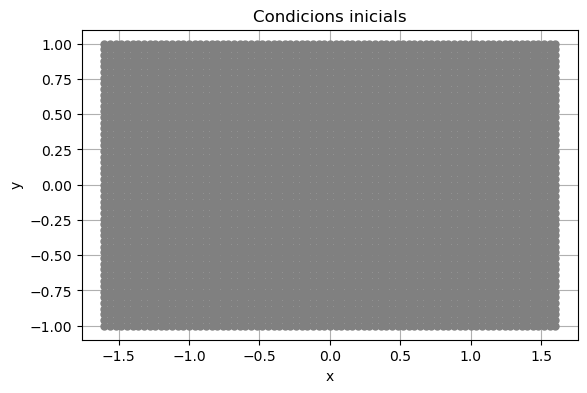

In [ ]:
# grafica_punts(condicions_inicials, dibuixa_regions=False)

### 2. Generar $n$ trajectòries, una per a cada posició inicial

In [1057]:
trajectories = generar_trajectories(edo_duffing, condicions_inicials, t_span, t_valors)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (4131, 400, 2)


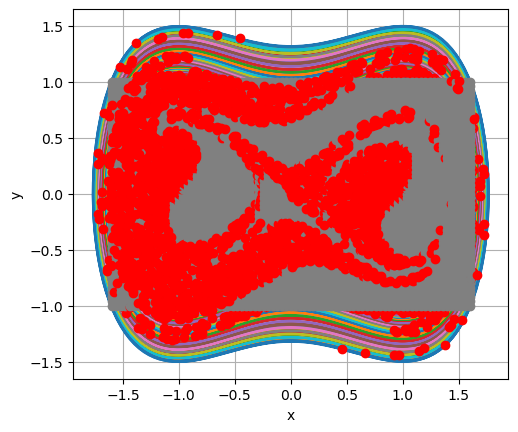

In [1058]:
# grafica_trajectories(trajectories, dibuixa_regions=False)

In [1059]:
exemples = np.array((trajectories[0], trajectories[1165], trajectories[1323]))
# grafica_trajectories(exemples)

### 3. Calcular distàncies $r_{ij}$ entre trajectòries i crear graf $G = (V, E, W)$

Els vèrtexs són cadascuna de les $n$ trajectòries: $V=\{v_1,...,v_n\}$.

Cada aresta $e_{ij}\in E\subseteq V\times V$ està associada al pes $w_{ij}\in W\in\R^{n\times n}$, on $W$ és la matriu de similaritat i $w_{ij} = 1/r_{ij}$. Cada pes representa quant de properes són dues trajectòries ($0 \rightarrow$ poc, i $\infty \rightarrow$ molt).

### 4 Matriu de similaritat

In [1060]:
matriu_pesos = calcula_matriu_pesos(trajectories, t_valors)

In [1061]:
imprimeix_estadistics(matriu_pesos)

Dimensions de la matriu de pesos: (4131, 4131)
pes_min      0.295
pes_mediana  0.706
pes_mitja    0.880
percentil90  1.298
percentil95  1.781
pes_max      115.948


In [1062]:
matriu_similaritat_W, sparsification_tol, sparsification_percent = \
    sparcify(matriu_pesos, percent=95)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{sparsification_tol:.3f}")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
# print(matriu_similaritat_W)

S'ha obtingut una esparsificació del 95% usant una tolerància de 1.781


### 5. Calcular la matriu diagonal de graus $D$, on $D_{ii}=\sum _{j=0}^{n} w_{ij}$

In [1063]:
matriu_grau_D = calcula_matriu_grau(matriu_similaritat_W)

### 6. Descomposició espectral: $Lu =\lambda Du$

In [1064]:
vaps, veps = calcula_vaps_veps(matriu_grau_D, matriu_similaritat_W, max_clusters)
print("vaps.shape =", vaps.shape)
print("veps.shape =", veps.shape)
vaps = vaps[1:] # eliminem el VAP més petit perquè és zero
print("vaps.shape =",vaps.shape)

vaps.shape = (41,)
veps.shape = (4131, 41)
vaps.shape = (40,)


### 7. Estimació del nombre de clústers $k$ = argmin [max($g_i$)]

In [1065]:
print("nombre de clusters =", num_clusters := calcula_num_clusters(vaps))

nombre de clusters = 7


### 8. $k$-means

In [1066]:
labels = troba_clusters(num_clusters, veps)

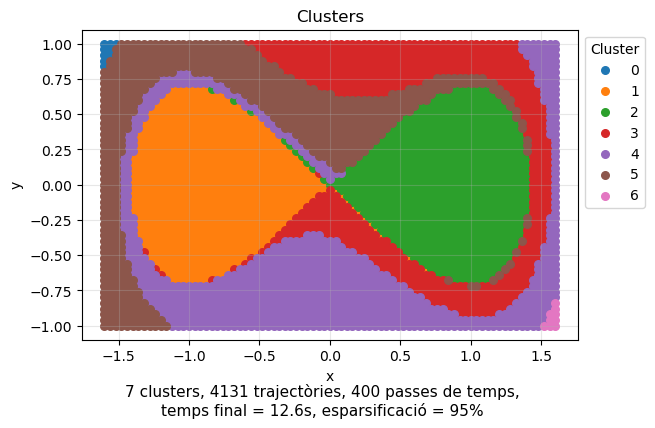

In [1070]:
grafica_clusters(condicions_inicials, labels, num_clusters, sparsification_tol, sparsification_percent, t_steps, t_span)